### This section contains Exploratory Data Analysis<br>
Objective of this section is to understand dataset and identify the pattern<br>

#### First step in understanding the data is to identify and state the problem <br>
various term to understand first 
1) churn rate : Churn rate is the percentage of customers who stop using a company's product or service during a given time period.
target column = churn  
Yes → Customer left the company.
No → Customer stayed.
For businesses, a high churn rate means they're losing customers quickly. That's expensive because acquiring a new customer usually costs more than retaining an existing one.

The purpose of my machine learning model is to predict which customers are likely to churn, so the company can intervene with targeted offers, better support, or personalized retention campaigns before those customers leave.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(10) #to show first 10 rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [ ]:
###Basic EDA 
df.info()  


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

np.int64(0)

###Observation 

All the columns which are categorical are of dtype = "str" which should be converted to "category"
TotalCharges column has Dtype as str but it should be float
SeniorCitizen column has Dtype as int but it shoudl be category


In [23]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors = "coerce")
categorical_data = df.select_dtypes(include = "str").columns
df[categorical_data] = df[categorical_data].astype("category")
df.info() 
#doing changing dtype will also help in saving memory


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   customerID        7043 non-null   category
 1   gender            7043 non-null   category
 2   SeniorCitizen     7043 non-null   int64   
 3   Partner           7043 non-null   category
 4   Dependents        7043 non-null   category
 5   tenure            7043 non-null   int64   
 6   PhoneService      7043 non-null   category
 7   MultipleLines     7043 non-null   category
 8   InternetService   7043 non-null   category
 9   OnlineSecurity    7043 non-null   category
 10  OnlineBackup      7043 non-null   category
 11  DeviceProtection  7043 non-null   category
 12  TechSupport       7043 non-null   category
 13  StreamingTV       7043 non-null   category
 14  StreamingMovies   7043 non-null   category
 15  Contract          7043 non-null   category
 16  PaperlessBilling  7043 non-null   c

In [24]:
print(df.shape)
df.describe()

(7043, 21)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [25]:
print("Missing Values:")
display(df.isnull().sum())

print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Missing Values:


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


Duplicate Rows: 0


# UNIVARIATE ANALYSIS

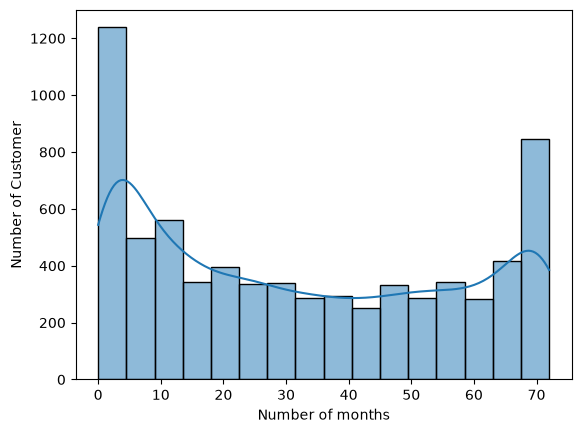

In [33]:
sns.histplot(df["tenure"],kde = True)
plt.xlabel("Number of months")
plt.ylabel("Number of Customer")
plt.show()


#Observation 
- distribution is kind of bimodal 
- There is concentration of customers near both extreme ends which indicates two groups : **newer customer** and **loyal customer**

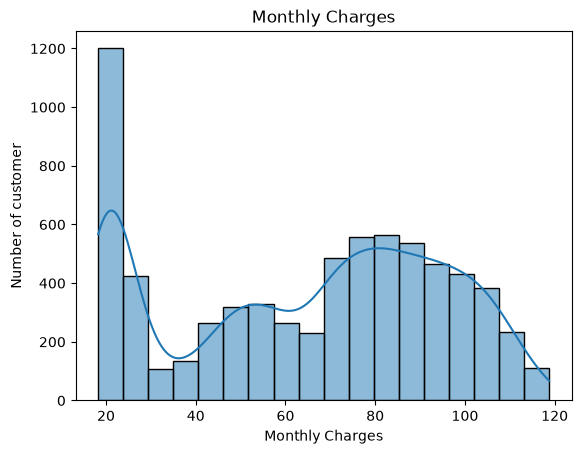

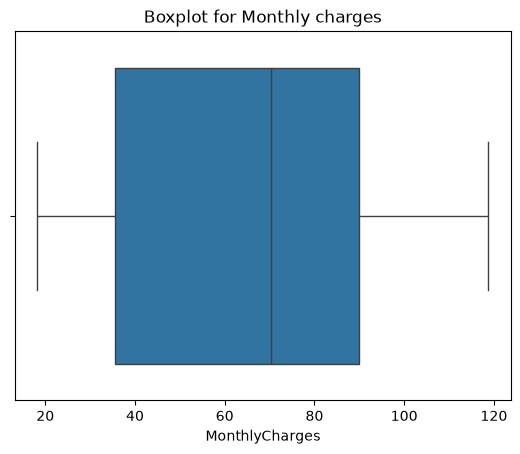

In [36]:
sns.histplot(df["MonthlyCharges"],kde = True)
plt.title("Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Number of customer")
plt.show()
sns.boxplot(x=df["MonthlyCharges"])
plt.title("Boxplot for Monthly charges")
plt.show()

### Observation

- Monthly charges range from approximately \$18 to \$120.
- The distribution is **bimodal**, with prominent peaks around **\$20–25** and **\$75–90**.
- This suggests the presence of at least two major customer segments, likely representing customers with basic service plans and customers with more comprehensive or premium plans.
- The distribution is not symmetric and does not follow a normal distribution.
- The median monthly charge is approximately **$70**.
- No significant outliers are observed in the distribution of monthly charges.

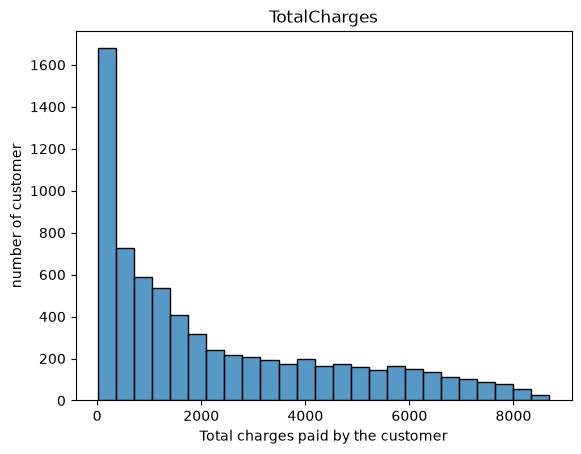

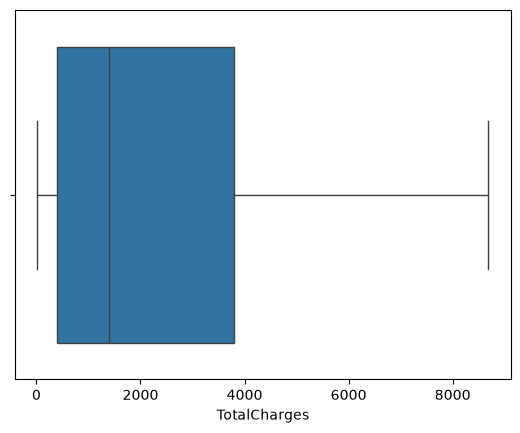

In [41]:
sns.histplot(df["TotalCharges"])
plt.title("TotalCharges")
plt.xlabel("Total charges paid by the customer")
plt.ylabel("number of customer")
plt.show()
sns.boxplot(x=df["TotalCharges"])
plt.show()

### Observation
- graph for Total charges is right skewed
- a lot of customers which lies in (0$ - 200$) are newer customer base and at the right end are loyal customer base
- No significant outliers are detected according to the IQR criterion, suggesting that the high total charge values are genuine and likely correspond to long-term customers with higher monthly subscriptions.
- Since TotalCharges is influenced by both MonthlyCharges and customer tenure, customers with longer service duration and higher monthly plans naturally accumulate larger total charges. Therefore, the observed right-skewed distribution is expected and reflects differences in customer lifetime value rather than data anomalies.




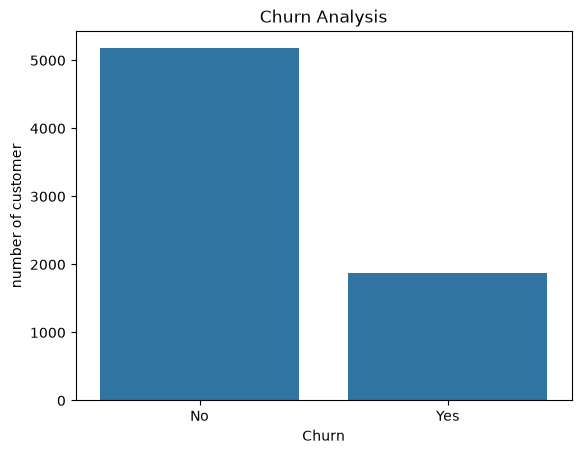

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [45]:
sns.countplot(x=df["Churn"])
plt.title("Churn Analysis")
plt.ylabel("number of customer")
plt.show()
df.value_counts(df["Churn"],normalize=True)

### Observation
- Approximately **26.5%** of customers have churned, while **73.5%** have remained with the company.
- The dataset exhibits a moderate class imbalance, with the majority class corresponding to customers who did not churn.

# Bivariate Analysis

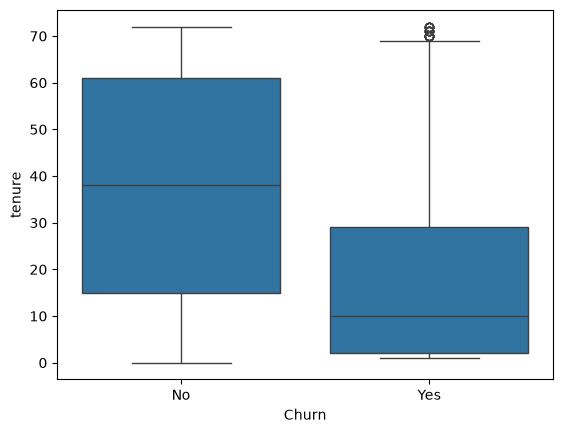

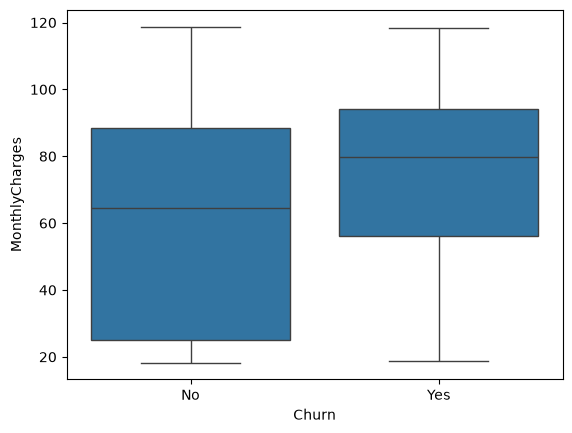

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

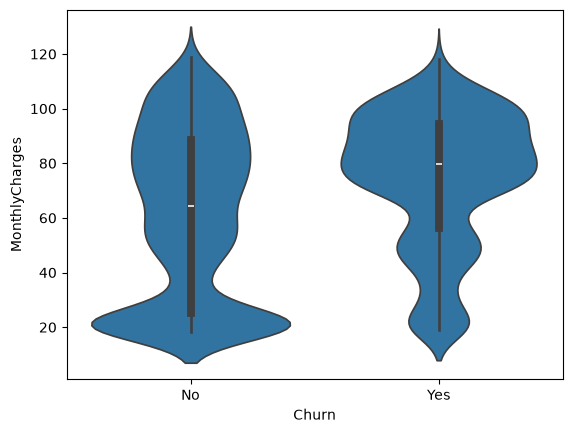

In [48]:
sns.boxplot(data=df,
            x="Churn",
            y="tenure")
plt.show()
sns.boxplot(data=df,
            x="Churn",
            y="MonthlyCharges")
plt.show()
sns.violinplot(data=df,
               x="Churn",
               y="MonthlyCharges")

### Observation

- Customers who churned generally have much lower tenure than customers who stayed.
- The median tenure for churned customers is substantially lower.
- A small number of long-term customers also churned, indicating that even loyal customers are not completely immune to churn.
- Customers who churn generally have higher monthly charges than customers who remain.
- The median monthly charge is noticeably higher for churned customers.

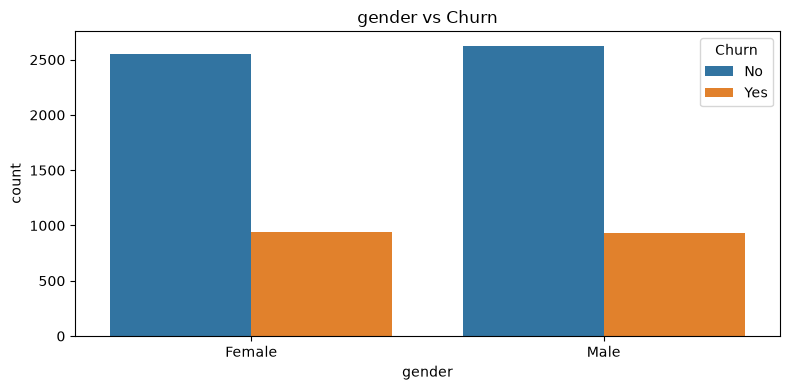


Percentage Table


Churn,No,Yes
gender,,
Female,73.1,26.9
Male,73.8,26.2


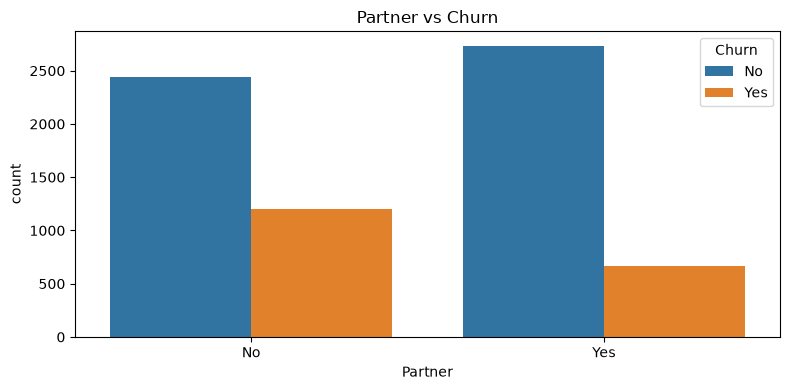


Percentage Table


Churn,No,Yes
Partner,,
No,67.0,33.0
Yes,80.3,19.7


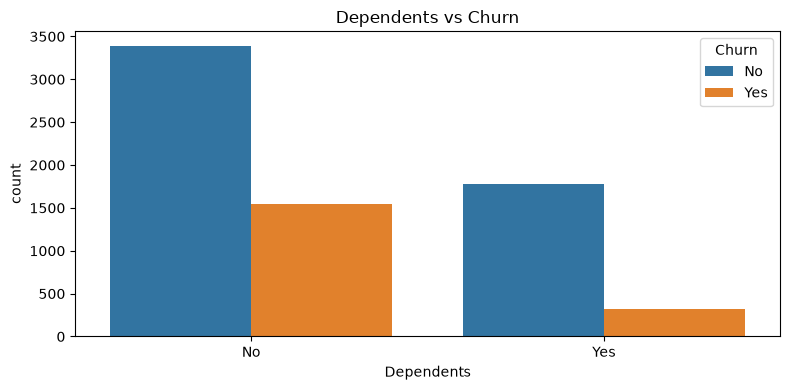


Percentage Table


Churn,No,Yes
Dependents,,
No,68.7,31.3
Yes,84.5,15.5


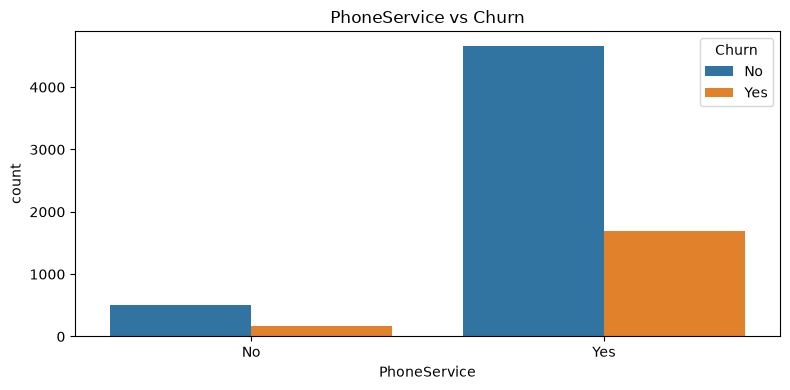


Percentage Table


Churn,No,Yes
PhoneService,,
No,75.1,24.9
Yes,73.3,26.7


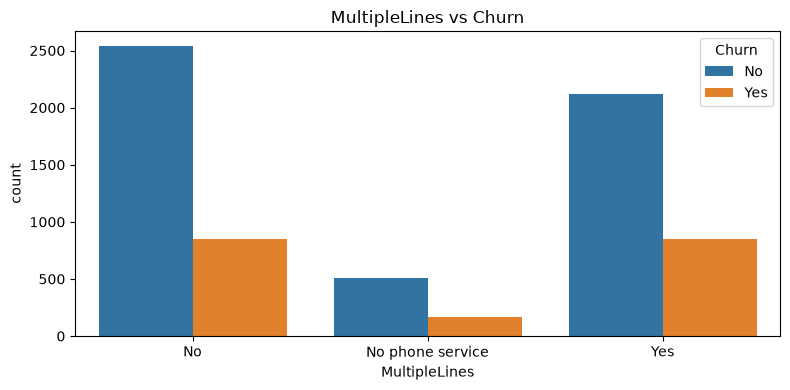


Percentage Table


Churn,No,Yes
MultipleLines,,
No,75.0,25.0
No phone service,75.1,24.9
Yes,71.4,28.6


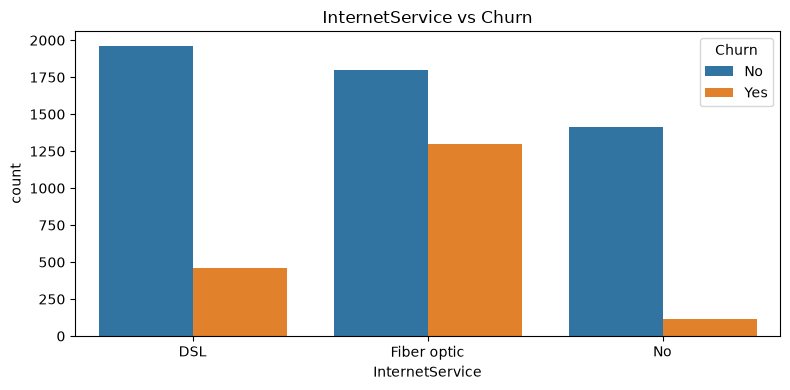


Percentage Table


Churn,No,Yes
InternetService,,
DSL,81.0,19.0
Fiber optic,58.1,41.9
No,92.6,7.4


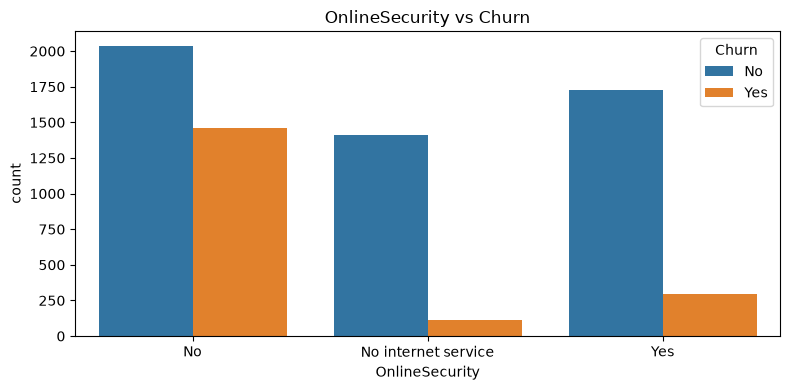


Percentage Table


Churn,No,Yes
OnlineSecurity,,
No,58.2,41.8
No internet service,92.6,7.4
Yes,85.4,14.6


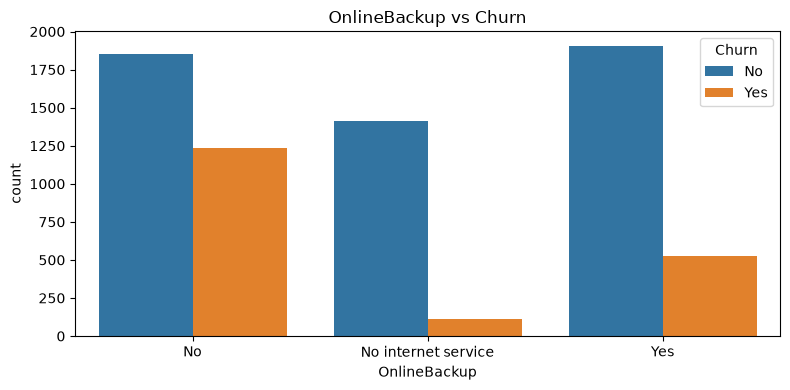


Percentage Table


Churn,No,Yes
OnlineBackup,,
No,60.1,39.9
No internet service,92.6,7.4
Yes,78.5,21.5


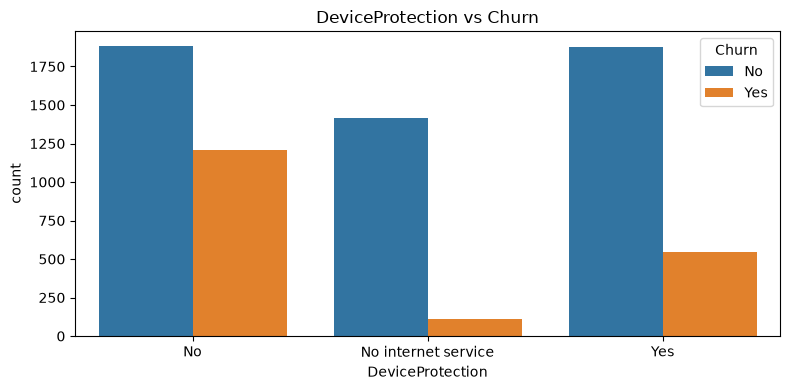


Percentage Table


Churn,No,Yes
DeviceProtection,,
No,60.9,39.1
No internet service,92.6,7.4
Yes,77.5,22.5


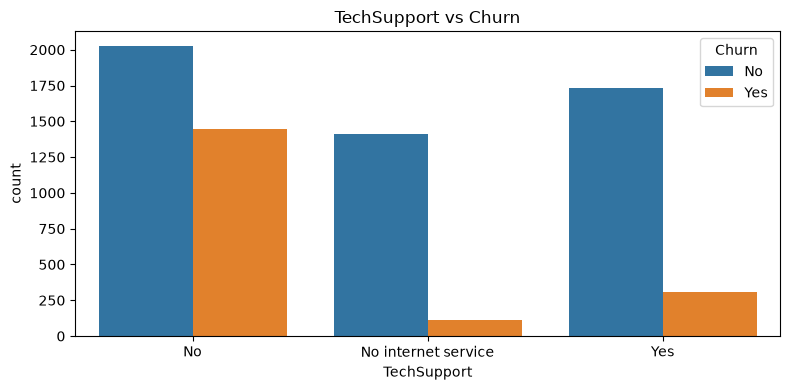


Percentage Table


Churn,No,Yes
TechSupport,,
No,58.4,41.6
No internet service,92.6,7.4
Yes,84.8,15.2


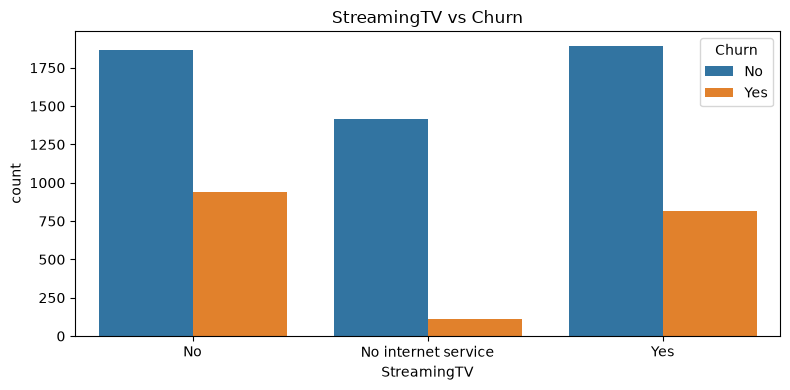


Percentage Table


Churn,No,Yes
StreamingTV,,
No,66.5,33.5
No internet service,92.6,7.4
Yes,69.9,30.1


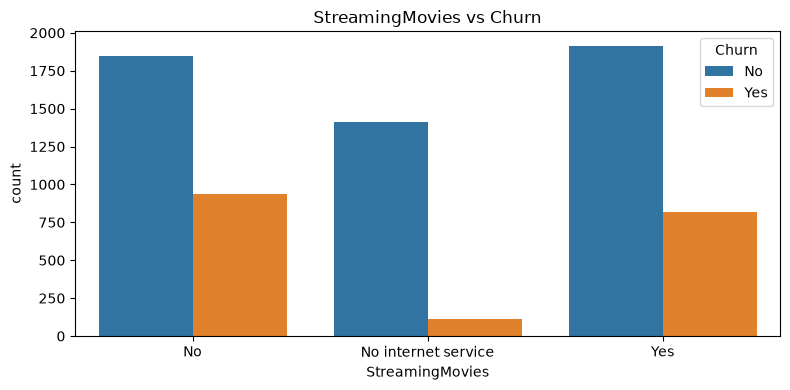


Percentage Table


Churn,No,Yes
StreamingMovies,,
No,66.3,33.7
No internet service,92.6,7.4
Yes,70.1,29.9


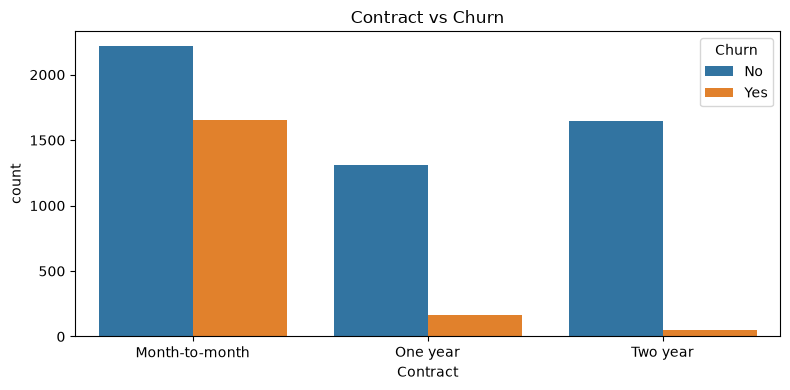


Percentage Table


Churn,No,Yes
Contract,,
Month-to-month,57.3,42.7
One year,88.7,11.3
Two year,97.2,2.8


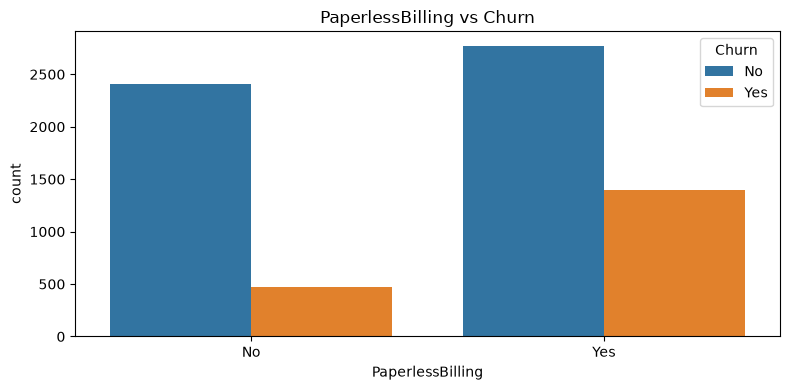


Percentage Table


Churn,No,Yes
PaperlessBilling,,
No,83.7,16.3
Yes,66.4,33.6


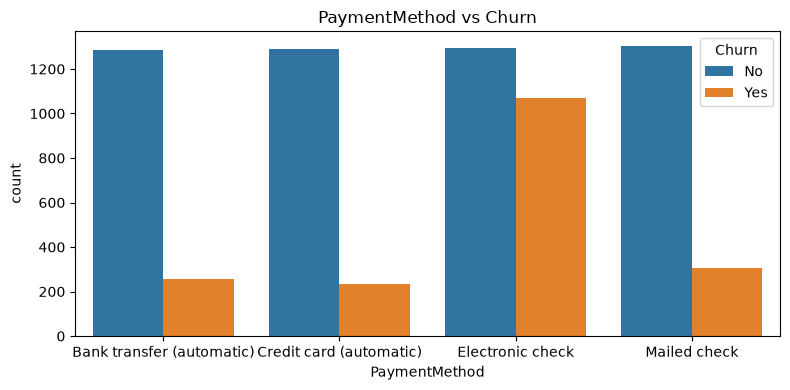


Percentage Table


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.3,16.7
Credit card (automatic),84.8,15.2
Electronic check,54.7,45.3
Mailed check,80.9,19.1


In [52]:
categorical_cols = [
    col for col in df.select_dtypes(include=["object", "category"]).columns
    if col != "Churn" and col != "customerID" 
]

for col in categorical_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=col,
        hue="Churn"
    )

    plt.title(f"{col} vs Churn")
    plt.tight_layout()
    plt.show()

    print("\nPercentage Table")
    display(
        pd.crosstab(
            df[col],
            df["Churn"],
            normalize="index"
        ).round(3)*100
    )

### Observation

- Customers on month-to-month contracts exhibit the highest churn rate.
- Contract type is one of the strongest predictors of churn. Encouraging customers to migrate from month-to-month contracts to longer-term contracts through discounts or loyalty incentives may significantly improve customer retention.
- Customers paying through electronic checks exhibit the highest churn rate.


# Key takeaways
1. Customer churn is moderately imbalanced
Around 26.5% of customers have churned, while 73.5% have remained.
The dataset is moderately imbalanced, so evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC should be considered in addition to accuracy.


2. Customer tenure is strongly associated with churn
Churned customers generally have much shorter tenure.
Most customers who leave do so during the early months of their relationship with the company.
This suggests that early customer engagement and onboarding could significantly reduce churn.


3. Monthly charges reveal distinct customer segments
Monthly charges show a bimodal distribution, indicating different pricing/service plans.
Customers with higher monthly charges tend to churn more frequently than those with lower charges.


4. Total charges are driven by tenure
Total charges are right-skewed because long-term customers naturally accumulate larger bills.
High total charges alone should not be interpreted as a churn risk without considering tenure.


5. Contract type is one of the strongest churn indicators
Customers with month-to-month contracts have the highest churn.
Longer-term contracts (one-year and two-year) are associated with much better retention.